# Task 3: Heart Disease Prediction

**Objective:** Build a machine learning model that predicts whether a patient has heart disease based on clinical measurements. This is a binary classification problem (0 = no disease, 1 = disease).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print('Libraries Imported Successfully.')

Libraries Imported Successfully.


In [5]:
# Loading and checking data

df = pd.read_csv("heart.csv")
print('Shape', df.shape)
print(df.head())

Shape (1025, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [6]:
# Checking missing values and target balance

print('Missing values:')
print(df.isnull().sum())

print('\nTarget Distribution')
print(df['target'].value_counts())

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Target Distribution
target
1    526
0    499
Name: count, dtype: int64


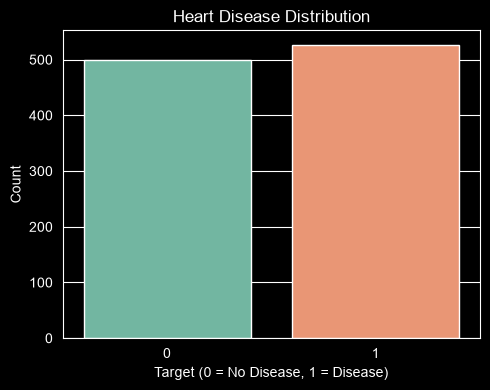

In [11]:
# Visualization of Data

plt.figure(figsize=(5,4))
sns.countplot(data=df, x='target',hue='target', palette='Set2', legend=False)
plt.title('Heart Disease Distribution')
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [12]:
# Splitting feature and target

X = df.drop('target', axis=1)
y = df['target']

print('X Shape', X.shape)
print('y Shape', y.shape)

X Shape (1025, 13)
y Shape (1025,)


In [14]:
# Test-train Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training det size: ', X_train.shape)
print('Testing set size: ', X_test.shape)

Training det size:  (820, 13)
Testing set size:  (205, 13)


In [15]:
# Scale features

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
# Training the Model

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print('Model Trained Successfully')

Model Trained Successfully


In [17]:
# Prediction and Evaluation

y_pred = model.predict(X_test)
print('Accuracy : ', accuracy_score(y_test, y_pred))

Accuracy :  0.7951219512195122


In [19]:
# Deeper Evaluation

print(confusion_matrix(y_test, y_pred))
print('\n')
print(classification_report(y_test, y_pred))

[[73 29]
 [13 90]]


              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



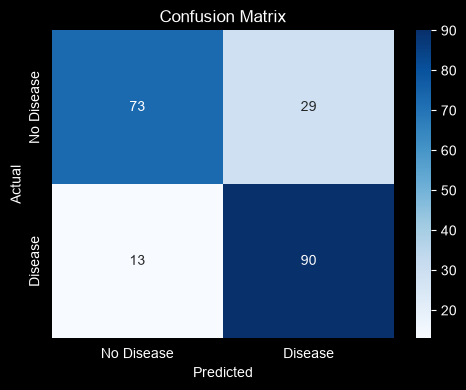

In [21]:
# Visualization of Prediction

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

#Summary
1. Data contains 1025 rows(patients) and 14 columns(features)
2. Data is complete, clean and with almost equal distribution of TARGET(persons having disease and no disease)
3. Model achieved 79.5% accuracy
4. Confusion matrix: For all the patients, it predicted 76% with disease and 85% with no disease correctly. Although it is good accuracy, it gave false alarm(predicted disease while healthy) 14% and, the most dangerous thing, predicted healthy while having disease 6%, of our sample data
5. Although it gave a great accuracy, we should only consider it if it says a patient has disease. For predicting NO DISEASE, we should do further testing to be on safe side.